In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

In [3]:
df=pd.read_csv('diabetes_prediction_dataset.csv')
df=pd.DataFrame(df)
df.head()


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


# Data Exploration

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [5]:
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
null=df.isnull().sum()
null

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(3854)

In [8]:
drop_dup=df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [9]:
# how imbalanced is the target?
df['diabetes'].value_counts()  

diabetes
0    87664
1     8482
Name: count, dtype: int64

In [10]:
# show hypertension imbalance
df['hypertension'].value_counts()

hypertension
0    88685
1     7461
Name: count, dtype: int64

In [11]:
# show the heart disease imbalance
df['heart_disease'].value_counts()

heart_disease
0    92223
1     3923
Name: count, dtype: int64

In [12]:
# how many genres are there?
df['gender'].unique()
df['gender'].value_counts()

gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

In [13]:
#replace the 'other' value in the gender to null
df['gender'].replace('Other', np.nan, inplace=True) 

In [14]:
df.isnull().sum()

gender                 18
age                     0
hypertension            0
heart_disease           0
smoking_history         0
bmi                     0
HbA1c_level             0
blood_glucose_level     0
diabetes                0
dtype: int64

In [15]:
#replace null values in gender with the most frequent value
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

In [16]:
# how many genres are there?
df['gender'].unique()
df['gender'].value_counts()

gender
Female    56179
Male      39967
Name: count, dtype: int64

In [17]:
# show the different entries
df['smoking_history'].unique()

array(['never', 'No Info', 'current', 'former', 'ever', 'not current'],
      dtype=object)

# Data Visualization

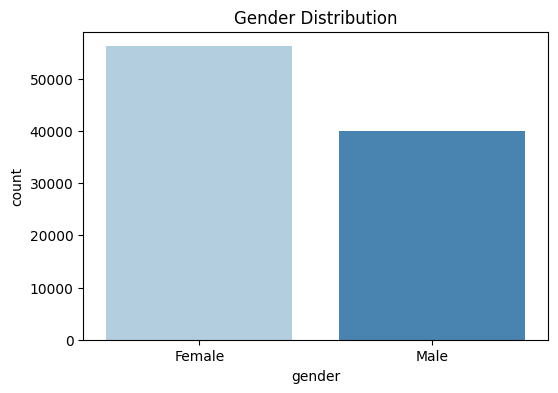

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x='gender', data=df, palette='Blues')
plt.title('Gender Distribution')
plt.show()

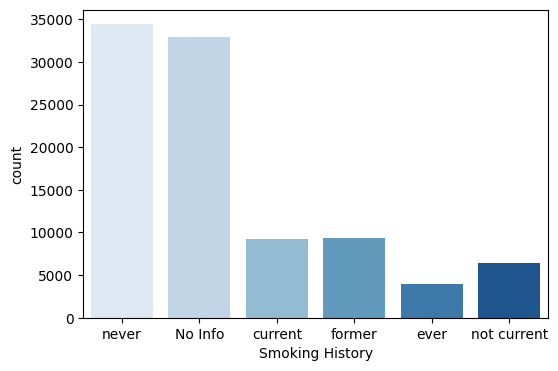

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='smoking_history', data=df, palette='Blues')
plt.xlabel('Smoking History')
plt.show()

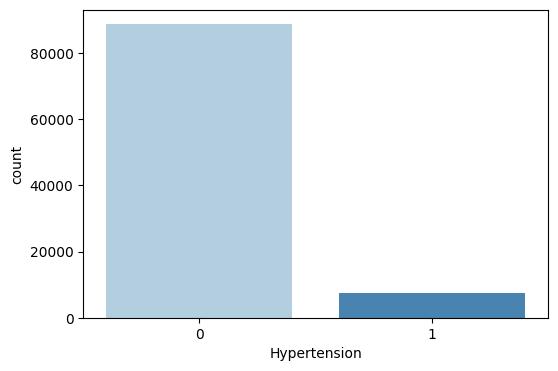

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='hypertension', data=df, palette='Blues')
plt.xlabel('Hypertension')
plt.show()

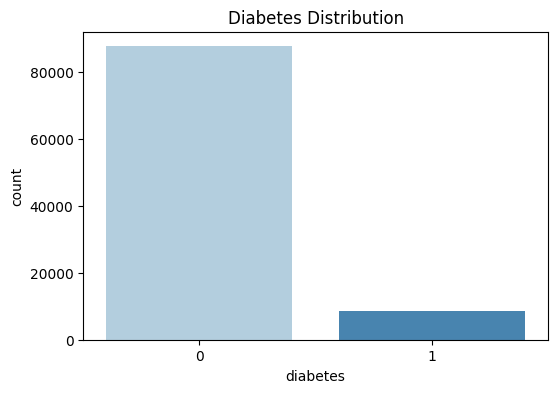

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df, palette='Blues')
plt.title("Diabetes Distribution")
plt.show()

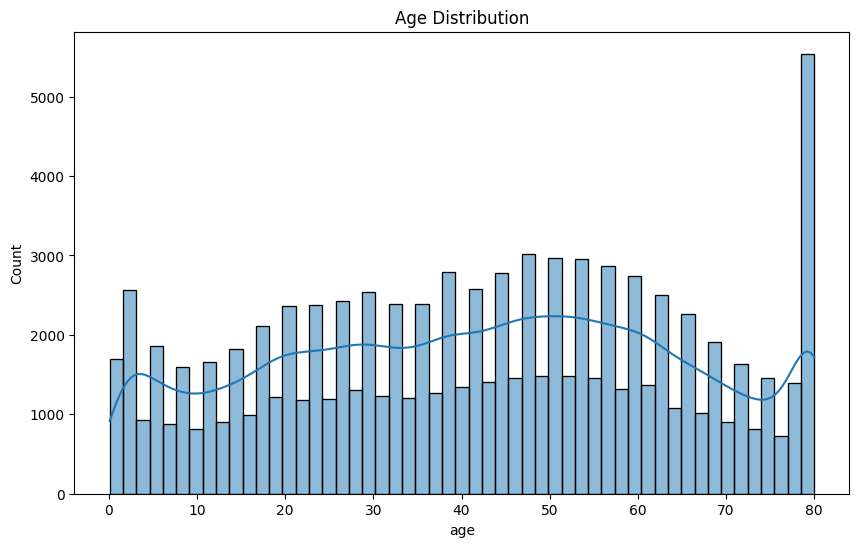

In [22]:
plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True, palette='Blues')
plt.title('Age Distribution')
plt.show()

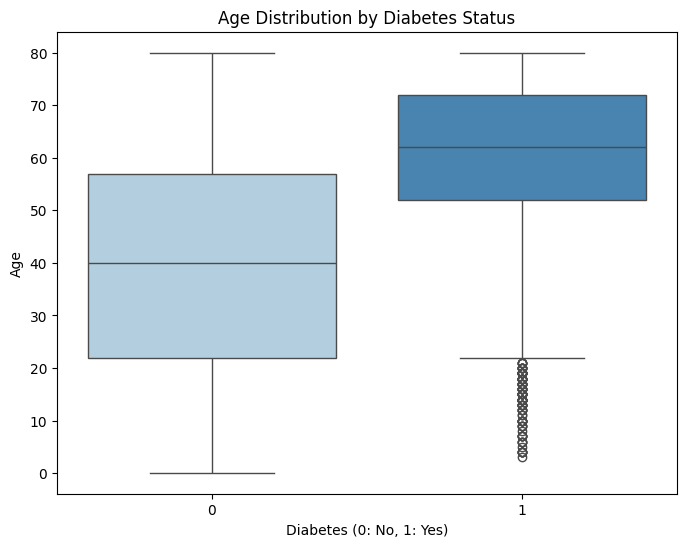

In [23]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='diabetes', y='age', data=df, palette='Blues')
plt.title('Age Distribution by Diabetes Status')
plt.xlabel('Diabetes (0: No, 1: Yes)')
plt.ylabel('Age')
plt.show()

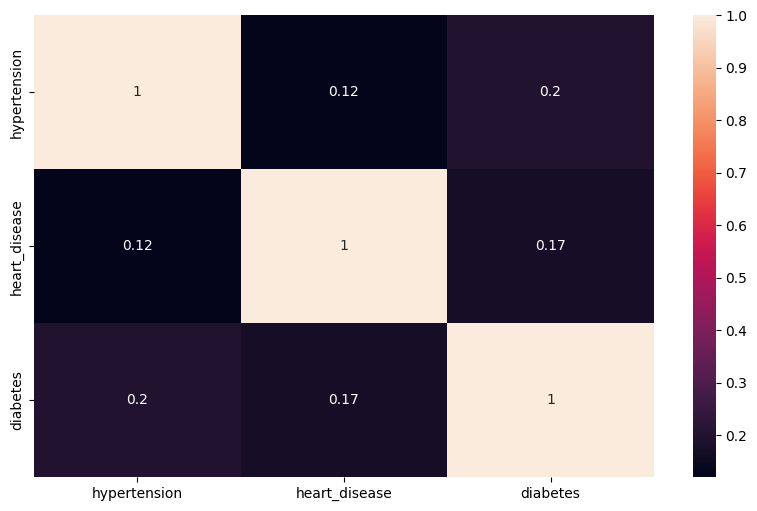

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df[["hypertension", "heart_disease", "diabetes"]].corr(), annot=True)
plt.show()

# Preprocessing

In [25]:
import pandas as pd
df = pd.get_dummies(df,columns=['smoking_history'],drop_first=True) 
df = df.replace({True: 1, False: 0})

In [26]:
df.dtypes

gender                          object
age                            float64
hypertension                     int64
heart_disease                    int64
bmi                            float64
HbA1c_level                    float64
blood_glucose_level              int64
diabetes                         int64
smoking_history_current          int64
smoking_history_ever             int64
smoking_history_former           int64
smoking_history_never            int64
smoking_history_not current      int64
dtype: object

# Encoding

In [27]:
le = LabelEncoder()
df['gender'] = le.fit_transform(df['gender'])

In [28]:
df['gender']

0        0
1        0
2        1
3        0
4        1
        ..
99994    0
99996    0
99997    1
99998    0
99999    0
Name: gender, Length: 96146, dtype: int64

# Scaling

In [29]:
numeric_columns=['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

In [30]:
scale = MinMaxScaler()
df[numeric_columns] = scale.fit_transform(df[numeric_columns])

# Split the data

In [31]:
x=df.drop('diabetes',axis=1)
y=df['diabetes']

In [32]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Machine learning models
logistic regression

In [33]:
#Apply logistic regression
l_reg=LogisticRegression()
l_reg.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
y_predect=l_reg.predict(x_test)
y_predect

array([0, 0, 1, ..., 0, 0, 0], shape=(19230,))

In [35]:
print("The Accuracy of logistic regression is: ", accuracy_score(y_test, y_predect))

The Accuracy of logistic regression is:  0.9573062922516901


In [36]:
print(classification_report(y_test, y_predect))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.86      0.62      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230



In [37]:
accuracy = accuracy_score(y_test, y_predect)
precision = precision_score(y_test, y_predect)
recall = recall_score(y_test, y_predect)
f1 = f1_score(y_test, y_predect)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

Accuracy:  0.9573
Precision: 0.8623
Recall:    0.6223
F1-Score:  0.7229


Confusion Matrix:
 [[17338   171]
 [  650  1071]]


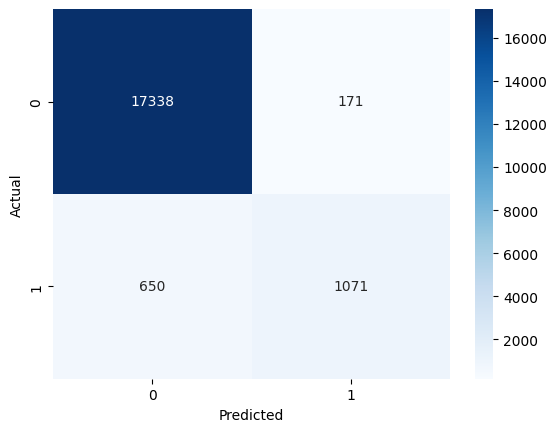

True Positives: 1071
True Negatives: 17338
False Positives: 171
False Negatives: 650


In [38]:
cm=confusion_matrix(y_test, y_predect)
print("Confusion Matrix:\n", cm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

tn, fp, fn, tp = cm.ravel()
print("True Positives:", tp)
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)

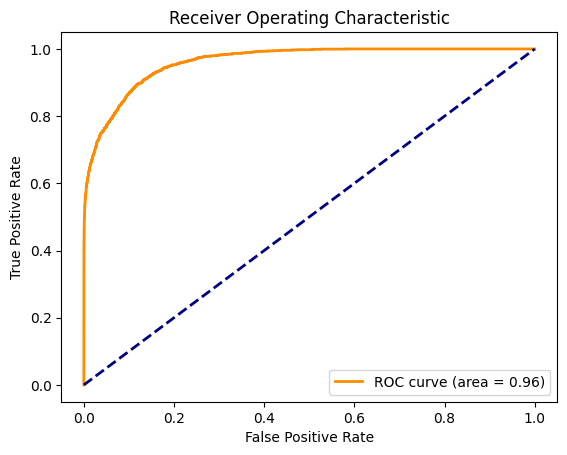

In [39]:
#roc curve
y_pred_prob = l_reg.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

Random Fores

In [40]:
#Apply Random Forest Classifier
ro_f=RandomForestClassifier()
ro_f.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
y_pred=ro_f.predict(x_test)
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(19230,))

In [42]:
print("The accuracy of rondom forest is: ", accuracy_score(y_test, y_pred))

The accuracy of rondom forest is:  0.9684347373894956


In [43]:
print(classification_report(y_test, y_predect))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.86      0.62      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230



In [44]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy:  {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall:    {recall:.4f}')
print(f'F1-Score:  {f1:.4f}')

Accuracy:  0.9684
Precision: 0.9449
Recall:    0.6874
F1-Score:  0.7958


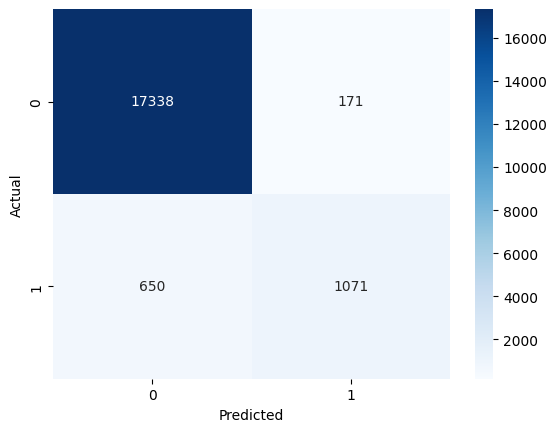

True Positives: 1071
True Negatives: 17338
False Positives: 171
False Negatives: 650


In [45]:
cm=confusion_matrix(y_test, y_predect)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

tn, fp, fn, tp = cm.ravel()
print("True Positives:", tp)
print("True Negatives:", tn)        
print("False Positives:", fp)
print("False Negatives:", fn)



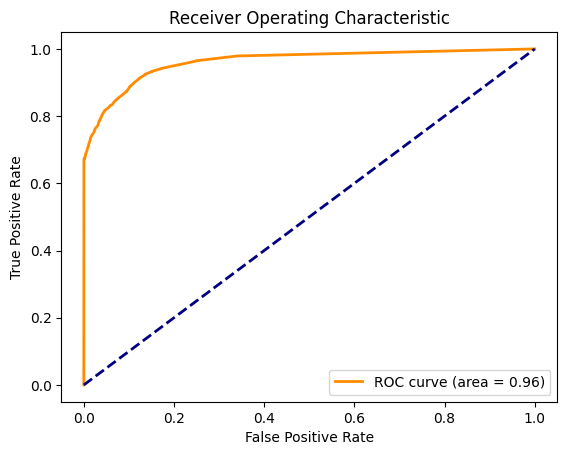

In [46]:
#roc curve for random forest
y_pred_prob = ro_f.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [47]:
#Apply Support vector machine
support_vm=SVC()
support_vm.fit(x_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [48]:
y_pred=support_vm.predict(x_test)
y_pred

array([0, 0, 1, ..., 0, 0, 0], shape=(19230,))

In [49]:
print("The accuracy of SVM is: ", accuracy_score(y_test, y_pred))

The accuracy of SVM is:  0.9595423816952678


In [50]:
print(classification_report(y_test, y_predect))

              precision    recall  f1-score   support

           0       0.96      0.99      0.98     17509
           1       0.86      0.62      0.72      1721

    accuracy                           0.96     19230
   macro avg       0.91      0.81      0.85     19230
weighted avg       0.95      0.96      0.95     19230



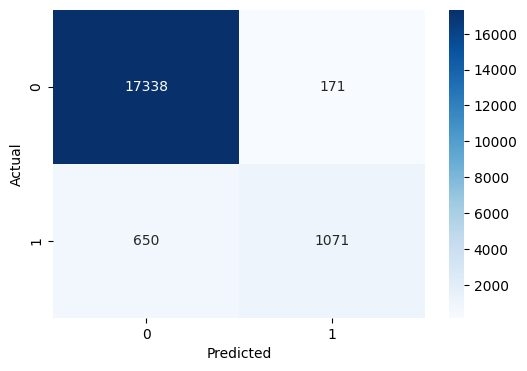

True Positives: 1071
True Negatives: 17338
False Positives: 171
False Negatives: 650


In [51]:
cm = confusion_matrix(y_test, y_predect)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

tn, fp, fn, tp = cm.ravel()
print("True Positives:", tp)
print("True Negatives:", tn)    
print("False Positives:", fp)
print("False Negatives:", fn)

In [52]:
#apply Gradient Boosting Classifier
gradient_vm=GradientBoostingClassifier()
gradient_vm.fit(x_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [53]:
print("The accuracy of Gradient Boosting is: ", accuracy_score(y_test, y_pred))

The accuracy of Gradient Boosting is:  0.9595423816952678


In [54]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      1.00      0.98     17509
           1       0.97      0.57      0.71      1721

    accuracy                           0.96     19230
   macro avg       0.96      0.78      0.85     19230
weighted avg       0.96      0.96      0.95     19230



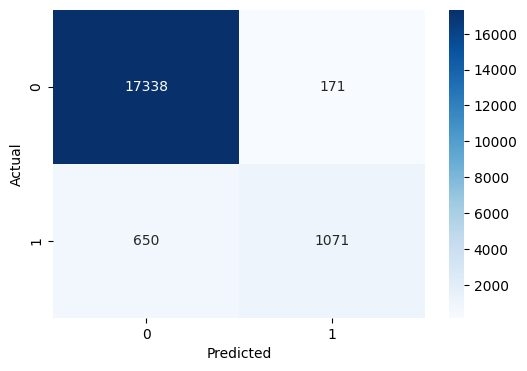

True Positives: 1071
True Negatives: 17338
False Positives: 171
False Negatives: 650


In [55]:
cm = confusion_matrix(y_test, y_predect)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
tn, fp, fn, tp = cm.ravel()
print("True Positives:", tp)
print("True Negatives:", tn)    
print("False Positives:", fp)
print("False Negatives:", fn)

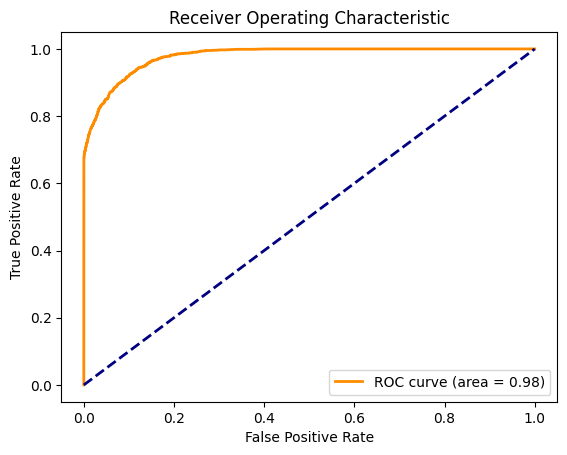

In [56]:
#roc curve for gradient boosting
y_pred_prob = gradient_vm.predict_proba(x_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr) 
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')        
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [57]:
#print the accuracy of all models and show the name of the best one and show only the 4 number after the decimal point
print("The accuracy of logistic regression is: ", f"{accuracy_score(y_test, y_predect):.4f}")
print("The accuracy of rondom forest is: ", f"{accuracy_score(y_test, y_pred):.4f}") 
print("The accuracy of SVM is: ", f"{accuracy_score(y_test, y_pred):.4f}")
print("The accuracy of Gradient Boosting is: ", f"{accuracy_score(y_test, y_pred):.4f}")
best_model = max(accuracy_score(y_test, y_predect), accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred))
best_model_name = "Logistic Regression" if max(accuracy_score(y_test, y_predect), accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred)) == accuracy_score(y_test, y_predect) else \
                  "Random Forest" if max(accuracy_score(y_test, y_predect), accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred)) == accuracy_score(y_test, y_pred) else \
                  "SVM" if max(accuracy_score(y_test, y_predect), accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred), accuracy_score(y_test, y_pred)) == accuracy_score(y_test, y_pred) else \
                  "Gradient Boosting"
print("The best model is: ", best_model_name)
print("The best model has an accuracy of: ", f"{best_model:.4f}")

The accuracy of logistic regression is:  0.9573
The accuracy of rondom forest is:  0.9595
The accuracy of SVM is:  0.9595
The accuracy of Gradient Boosting is:  0.9595
The best model is:  Random Forest
The best model has an accuracy of:  0.9595


In [64]:
import joblib
import os

try:
    joblib.dump(ro_f, 'diabetes_model.pkl')
    print("✅ Model (ro_f) saved!")
except NameError:
    print("❌ Error: Model name 'ro_f' not found.")


try:
    joblib.dump(scale, 'scaler.pkl')
    print("✅ MinMaxScaler (scale) saved!")
except NameError:
    print("❌ Error: Scaler name 'scale' not found. Check if you named it differently.")


try:
    joblib.dump(le, 'gender_encoder.pkl')
    print("✅ LabelEncoder (le) saved!")
except NameError:
    print("❌ Error: LabelEncoder name 'le' not found.")

print("\nLocation of files:", os.getcwd())

✅ Model (ro_f) saved!
✅ MinMaxScaler (scale) saved!
✅ LabelEncoder (le) saved!

Location of files: c:\Users\el_bostan\Desktop\مشروع FCAI\Diabetes Dataset
